In [ ]:
# ============================================================
# Mental Health Sentiment Analysis
# Step: Dataset Inspection (Section 3.3.1)
# ============================================================

import pandas as pd
import re
import string

# ── LOAD DATASET ─────────────────────────────────────────────
df = pd.read_csv('Combined Data.csv')

# ── 3.3.1 DATASET INSPECTION ─────────────────────────────────
print("=" * 55)
print("  DATASET INSPECTION")
print("=" * 55)

# Basic info
print(f"\n[1] Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n[2] Column Names  : {df.columns.tolist()}")

# First 5 rows
print(f"\n[3] First 5 Rows (Raw Data):")
print(df.head())

# Data types
print(f"\n[4] Data Types:")
print(df.dtypes)


# ── CLASS DISTRIBUTION ───────────────────────────────────────
print(f"\n{'='*55}")
print(f"  CLASS DISTRIBUTION")
print(f"{'='*55}")
print(f"\n[7] Label Counts:")
print(df['status'].value_counts())
print(f"\n[8] Label Percentages:")
print((df['status'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# ── SAMPLE TEXTS PER CLASS ───────────────────────────────────
print(f"\n{'='*55}")
print(f"  SAMPLE TEXT PER CLASS")
print(f"{'='*55}")
for label in df['status'].dropna().unique():
    sample = df[df['status'] == label]['statement'].dropna().iloc[0]
    print(f"\n  [{label}]")
    print(f"  {str(sample)[:120]}...")

# ── TEXT LENGTH STATS ────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  TEXT LENGTH STATISTICS")
print(f"{'='*55}")
df['word_count'] = df['statement'].dropna().apply(
    lambda x: len(str(x).split()))
print(f"\n[9] Word Count Stats:")
print(df['word_count'].describe().round(1))

print(f"\n{'='*55}")
print(f"  INSPECTION COMPLETE — Dataset is loaded and verified")
print(f"{'='*55}")

  DATASET INSPECTION

[1] Dataset Shape : 53,043 rows × 3 columns

[2] Column Names  : ['Unnamed: 0', 'statement', 'status']

[3] First 5 Rows (Raw Data):
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety

[4] Data Types:
Unnamed: 0     int64
statement     object
status        object
dtype: object

  MISSING VALUE INSPECTION

[5] Missing Values Per Column:
Unnamed: 0      0
statement     362
status          0
dtype: int64

[6] Total Missing Values : 362
     → 'statement' column : 362 null rows
     → 'status'    column : 0 null rows

  NOTE: 362 null rows exist in 'statement' column.
  These rows h

In [ ]:
# ============================================================
# CSC61304 - Assignment 3
# Mental Health Sentiment Analysis
# Step: Data Preprocessing
# ============================================================

import pandas as pd
import re
import string
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# ── 1. LOAD DATASET ─────────────────────────────────────────
df = pd.read_csv('Combined Data.csv')
print(f"[1] Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── 2. DROP JUNK COLUMN ─────────────────────────────────────
df.drop(columns=['Unnamed: 0'], inplace=True)
print(f"[2] Dropped unnamed index column")
# Check 1: Unnamed column gone
print(f"Columns remaining : {df.columns.tolist()}")
print(f"           Unnamed:0 removed  : {'Unnamed: 0' not in df.columns}")

# ── 3. HANDLE MISSING VALUES ────────────────────────────────
before = len(df)
df.dropna(subset=['statement'], inplace=True)
print(f"\n[3] Dropped {before - len(df)} null rows → {len(df):,} remaining")
# Check 2: No more null rows
print(f"Null values left  : {df['statement'].isnull().sum()}")
print(f"Missing rows gone  : {df['statement'].isnull().sum() == 0}")


# ── 4. TEXT CLEANING ────────────────────────────────────────
def clean_text(text):
    text = str(text).lower()                                          # lowercase
    text = re.sub(r'(?:https?://|www\.)\S+', '', text, flags=re.IGNORECASE)                       # remove URLs
    text = re.sub(r'<.*?>', '', text)                                 # remove HTML
    text = re.sub(r'\d+', '', text)                                   # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                         # remove extra spaces
    return text

df['cleaned_statement'] = df['statement'].apply(clean_text)
print(f"\n[4] Text cleaned: URLs, HTML tags, numbers, punctuation removed")
# Check 4: Show before vs after text sample
sample_idx = 1080
print(f"Text Cleaning Sample (row {sample_idx}):")
print(f"  BEFORE : {repr(df['statement'].iloc[sample_idx][:120])}")
print(f"  AFTER  : {repr(df['cleaned_statement'].iloc[sample_idx][:120])}")

# Check 5: Confirm no URLs, HTML, numbers remain
has_urls  = df['cleaned_statement'].str.contains(r'(https?://|www\.)', regex=True).sum()
has_html  = df['cleaned_statement'].str.contains(r'<.*?>').sum()
has_nums  = df['cleaned_statement'].str.contains(r'\d').sum()
print(f"Remaining URLs    : {has_urls}")
print(f"Remaining HTML    : {has_html}")
print(f"Remaining Numbers : {has_nums}")

# ── 5. REMOVE EMPTY ROWS AFTER CLEANING ─────────────────────
df = df[df['cleaned_statement'].str.strip().str.len() > 2]
print(f"\n[5] Final usable rows: {len(df):,}")
# Check 3: Before vs after row count
print(f"Rows before clean : 53,043")
print(f"           Rows after clean  : {len(df):,}")
print(f"           Total removed     : {53043 - len(df):,}")

# ── 6. LABEL ENCODING ───────────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['status'])
print(f"\n[6] Label Encoding:")
for i, cls in enumerate(le.classes_):
    print(f"     {cls:25s} → {i}")

# ── 7. TRAIN / TEST SPLIT (80/20, stratified) ───────────────
X = df['cleaned_statement']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # reproducibility
    stratify=y           # maintain class proportions
)
print(f"\n[7] Train/Test Split:")
print(f"     Train: {len(X_train):,} samples (80%)")
print(f"     Test : {len(X_test):,}  samples (20%)")

# ── 8. TF-IDF VECTORIZATION ─────────────────────────────────
# Why TF-IDF?
# - Converts raw text into numerical features the model can learn from
# - Rewards words that are distinctive to a class (high TF, low DF)
# - Penalises very common words across all documents (stopwords effect)
tfidf = TfidfVectorizer(
    max_features=15000,   # keep top 15,000 most informative words
    stop_words='english', # remove common words (the, is, are...)
    ngram_range=(1, 2),   # use single words AND two-word phrases
    min_df=3,             # ignore words appearing in < 3 documents
    sublinear_tf=True     # apply log(1 + tf) to reduce impact of very frequent words
)

X_train_tfidf = tfidf.fit_transform(X_train)  # fit on train only!
X_test_tfidf  = tfidf.transform(X_test)       # only transform test (no data leakage)

print(f"\n[8] TF-IDF Vectorization:")
print(f"     Vocabulary size  : {len(tfidf.vocabulary_):,} features")
print(f"     Train matrix     : {X_train_tfidf.shape}")
print(f"     Test matrix      : {X_test_tfidf.shape}")

# ── 9. SAVE FOR MODEL TRAINING ──────────────────────────────
os.makedirs('preprocessed', exist_ok=True)
pickle.dump(
    (X_train_tfidf, X_test_tfidf, y_train, y_test, le, tfidf),
    open('preprocessed/data.pkl', 'wb')
)
print(f"\n[9] Preprocessed data saved to preprocessed/data.pkl")
print(f"\n{'='*55}")
print(f"  PREPROCESSING COMPLETE")
print(f"  Samples : {len(df):,}")
print(f"  Features: {X_train_tfidf.shape[1]:,}")
print(f"  Classes : {len(le.classes_)} {list(le.classes_)}")
print(f"{'='*55}")

[1] Loaded dataset: 53,043 rows, 3 columns
[2] Dropped unnamed index column
Columns remaining : ['statement', 'status']
           Unnamed:0 removed  : True

[3] Dropped 362 null rows → 52,681 remaining
Null values left  : 0
Missing rows gone  : True

[4] Text cleaned: URLs, HTML tags, numbers, punctuation removed
Text Cleaning Sample (row 1080):
  BEFORE : 'Wooo hoooo!'
  AFTER  : 'wooo hoooo'


/tmp/ipykernel_626/3158627219.py:55: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_urls  = df['cleaned_statement'].str.contains(r'(https?://|www\.)', regex=True).sum()


Remaining URLs    : 0
Remaining HTML    : 0
Remaining Numbers : 0

[5] Final usable rows: 52,669
Rows before clean : 53,043
           Rows after clean  : 52,669
           Total removed     : 374

[6] Label Encoding:
     Anxiety                   → 0
     Bipolar                   → 1
     Depression                → 2
     Normal                    → 3
     Personality disorder      → 4
     Stress                    → 5
     Suicidal                  → 6

[7] Train/Test Split:
     Train: 42,135 samples (80%)
     Test : 10,534  samples (20%)

[8] TF-IDF Vectorization:
     Vocabulary size  : 15,000 features
     Train matrix     : (42135, 15000)
     Test matrix      : (10534, 15000)

[9] Preprocessed data saved to preprocessed/data.pkl

  PREPROCESSING COMPLETE
  Samples : 52,669
  Features: 15,000
  Classes : 7 ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


Data loaded successfully!
  Train : (42135, 15000)
  Test  : (10534, 15000)
  Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Model trained successfully!

  LOGISTIC REGRESSION — RESULTS
  Accuracy  : 0.7666  (76.66%)
  Precision : 0.7645
  Recall    : 0.7666
  F1-Score  : 0.7634

Per-Class Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.84      0.76      0.80       768
             Bipolar       0.87      0.74      0.80       556
          Depression       0.71      0.73      0.72      3081
              Normal       0.86      0.94      0.90      3267
Personality disorder       0.87      0.61      0.72       215
              Stress       0.66      0.49      0.56       517
            Suicidal       0.66      0.65      0.65      2130

            accuracy                           0.77     10534
           macro avg       0.78      0.70      0.74     10534
        weighted avg       0.76      0.77      0.76     10534



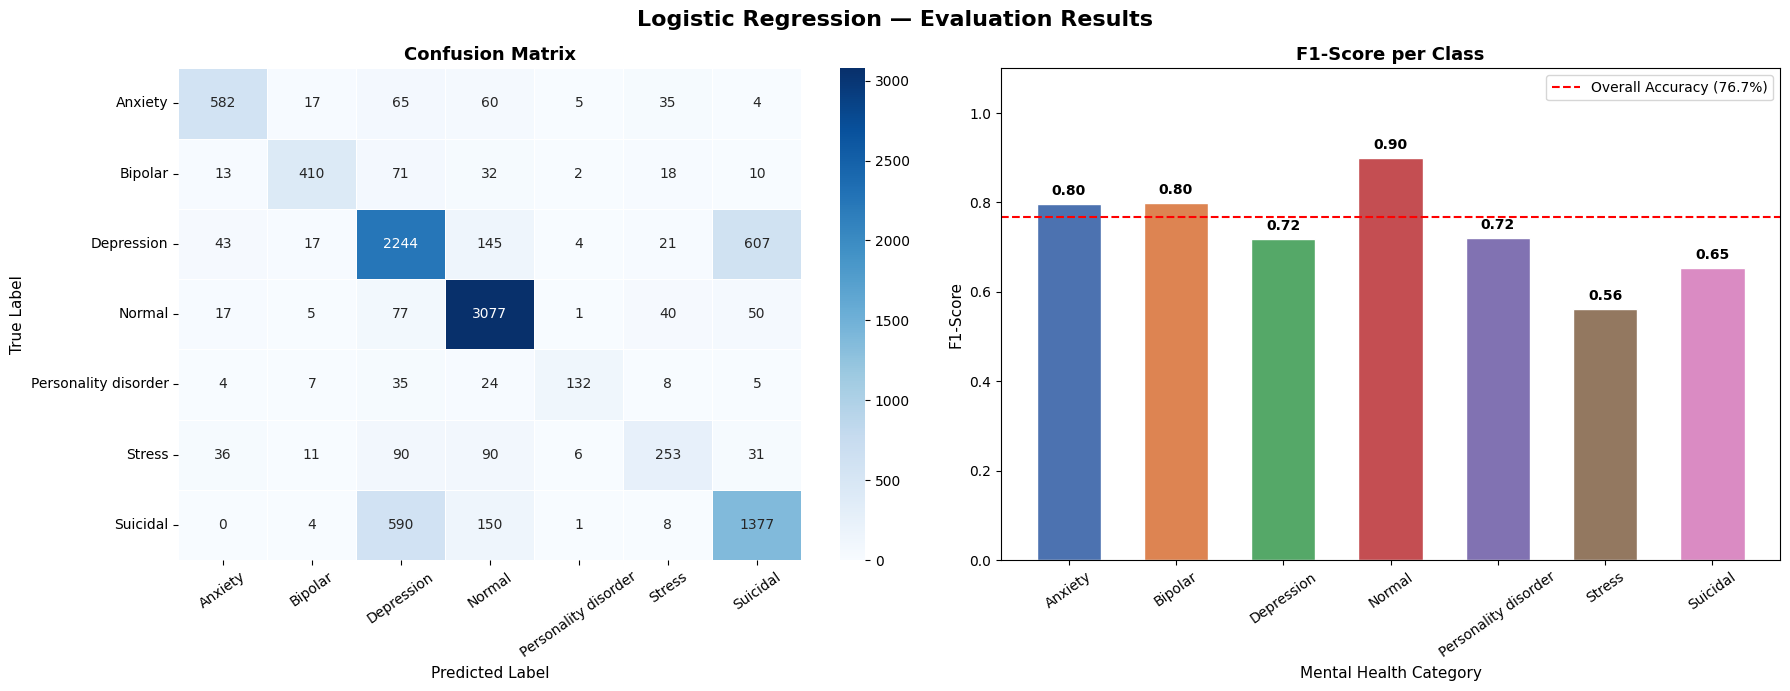


Chart saved as logistic_regression_results.png
Model saved as preprocessed/logistic_regression_model.pkl

  LIVE PREDICTION TEST WITH PRIORITY FLAG
  #   Predicted                Conf  Priority
  ------------------------------------------------------------

  [1] Input    : I feel so hopeless and empty, nothing makes me happy anymore
      Predicted : Depression
      Confidence: 93.1%
      Priority  : ROUTINE

  [2] Input    : I had a great day today, feeling really positive!
      Predicted : Normal
      Confidence: 49.0%
      Priority  : NEEDS HUMAN REVIEW

  [3] Input    : I can't stop worrying about everything, my heart is racing
      Predicted : Depression
      Confidence: 40.8%
      Priority  : NEEDS HUMAN REVIEW

  [4] Input    : I hear voices and my thoughts are all over the place
      Predicted : Normal
      Confidence: 51.3%
      Priority  : ROUTINE

  [5] Input    : The constant anxiety is overwhelming, I am shaking and sweat
      Predicted : Anxiety
      Confid

In [ ]:
# ============================================================
# CSC61304 - Assignment 3
# Mental Health Sentiment Analysis
# Step: Model Training - Logistic Regression (Primary Model)
# ============================================================

import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, precision_score,
                              recall_score, f1_score)

# ── 1. LOAD PREPROCESSED DATA ────────────────────────────────
X_train_tfidf, X_test_tfidf, y_train, y_test, le, tfidf = pickle.load(
    open('preprocessed/data.pkl', 'rb'))

print("Data loaded successfully!")
print(f"  Train : {X_train_tfidf.shape}")
print(f"  Test  : {X_test_tfidf.shape}")
print(f"  Classes: {list(le.classes_)}")

# ── 2. TRAIN LOGISTIC REGRESSION ─────────────────────────────
# Why Logistic Regression?
# - Learns a weight for every TF-IDF feature (10,000 words)
# - Unlike Naive Bayes, does NOT assume word independence
# - Linear decision boundary fits TF-IDF feature space naturally
# - C=5 controls regularization (higher C = less penalty = more flexible)
# - max_iter=1000 ensures the model fully converges
# - solver='lbfgs' handles multiclass efficiently

lr = LogisticRegression(
    C=5,
    max_iter=1000,
    solver='lbfgs',
    multi_class='auto',
    random_state=42
)

lr.fit(X_train_tfidf, y_train)
print(f"\nModel trained successfully!")

# ── 3. PREDICT ───────────────────────────────────────────────
y_pred = lr.predict(X_test_tfidf)

# ── 4. METRICS ───────────────────────────────────────────────
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print(f"\n{'='*55}")
print(f"  LOGISTIC REGRESSION — RESULTS")
print(f"{'='*55}")
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"{'='*55}")

print(f"\nPer-Class Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── 5. VISUALIZATION 1 — CONFUSION MATRIX HEATMAP ───────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Logistic Regression — Evaluation Results',
             fontsize=16, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            ax=axes[0],
            linewidths=0.5)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=0)

# ── 6. VISUALIZATION 2 — PER CLASS F1 SCORE BAR CHART ───────
report = classification_report(y_test, y_pred,
                                target_names=le.classes_,
                                output_dict=True)
classes   = le.classes_
f1_scores = [report[c]['f1-score'] for c in classes]
colors    = ['#4C72B0','#DD8452','#55A868','#C44E52',
             '#8172B2','#937860','#DA8BC3']

bars = axes[1].bar(classes, f1_scores, color=colors,
                   edgecolor='white', width=0.6)
axes[1].set_title('F1-Score per Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mental Health Category', fontsize=11)
axes[1].set_ylabel('F1-Score', fontsize=11)
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=35)
axes[1].axhline(y=acc, color='red', linestyle='--', linewidth=1.5,
                label=f'Overall Accuracy ({acc*100:.1f}%)')
axes[1].legend()
for bar, val in zip(bars, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('logistic_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as logistic_regression_results.png")

# ── 7. SAVE MODEL ────────────────────────────────────────────
pickle.dump(lr, open('preprocessed/logistic_regression_model.pkl', 'wb'))
print("Model saved as preprocessed/logistic_regression_model.pkl")

# ── 8. PRIORITY FLAG FUNCTION ────────────────────────────────
def get_priority(label, confidence):
    """
    Safety Threshold Logic:
    - Suicidal (any confidence) → always flagged, severity depends on confidence
    - Anxiety (high confidence) → High Risk
    - Any low confidence result → Human Review needed
    - Everything else          → Routine
    """
    if label == 'Suicidal':
        if confidence >= 70:
            priority = 'CRITICAL'
        else:
            # Even low confidence Suicidal is treated seriously
            priority = 'HIGH RISK'

    elif label == 'Anxiety' and confidence >= 70:
        priority = 'HIGH RISK'

    elif confidence < 50:
        priority = 'NEEDS HUMAN REVIEW'

    else:
        priority = 'ROUTINE'

    return priority

# ── 9. TEXT CLEANING FUNCTION ────────────────────────────────
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── 10. LIVE PREDICTION TEST ─────────────────────────────────
print(f"\n{'='*65}")
print("  LIVE PREDICTION TEST WITH PRIORITY FLAG")
print(f"{'='*65}")
print(f"  {'#':<3} {'Predicted':<22} {'Conf':>6}  {'Priority'}")
print(f"  {'-'*60}")

test_sentences = [
    "I feel so hopeless and empty, nothing makes me happy anymore",
    "I had a great day today, feeling really positive!",
    "I can't stop worrying about everything, my heart is racing",
    "I hear voices and my thoughts are all over the place",
    "The constant anxiety is overwhelming, I am shaking and sweating all the time and cannot calm down",
    "I just want to end it all, life has no meaning"
]

for i, sentence in enumerate(test_sentences, 1):
    cleaned    = clean_text(sentence)
    vectorized = tfidf.transform([cleaned])
    prediction = lr.predict(vectorized)[0]
    proba      = lr.predict_proba(vectorized)[0]
    confidence = proba.max() * 100
    label      = le.inverse_transform([prediction])[0]
    priority   = get_priority(label, confidence)

    print(f"\n  [{i}] Input    : {sentence[:60]}")
    print(f"      Predicted : {label}")
    print(f"      Confidence: {confidence:.1f}%")
    print(f"      Priority  : {priority}")

print(f"\n{'='*65}")
print("  PRIORITY FLAG LEGEND")
print(f"{'='*65}")
print("  CRITICAL                    → Suicidal + confidence >= 70%")
print("  HIGH RISK                   → Suicidal + confidence < 70%")
print("  HIGH RISK                   → Anxiety  + confidence >= 70%")
print("  NEEDS HUMAN REVIEW          → Any label + confidence < 50%")
print("  ROUTINE                     → All other predictions")
print(f"{'='*65}")

Data loaded successfully!
  Train : (42135, 15000)
  Test  : (10534, 15000)
  Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']

Training Random Forest... (this may take a few minutes)
Model trained successfully!

  RANDOM FOREST — RESULTS
  Accuracy  : 0.7327  (73.27%)
  Precision : 0.7440
  Recall    : 0.7327
  F1-Score  : 0.7228

Per-Class Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.85      0.64      0.73       768
             Bipolar       0.94      0.63      0.76       556
          Depression       0.64      0.74      0.69      3081
              Normal       0.79      0.95      0.86      3267
Personality disorder       1.00      0.44      0.61       215
              Stress       0.86      0.32      0.46       517
            Suicidal       0.68      0.57      0.62      2130

            accuracy                           0.73     10534
           macro avg

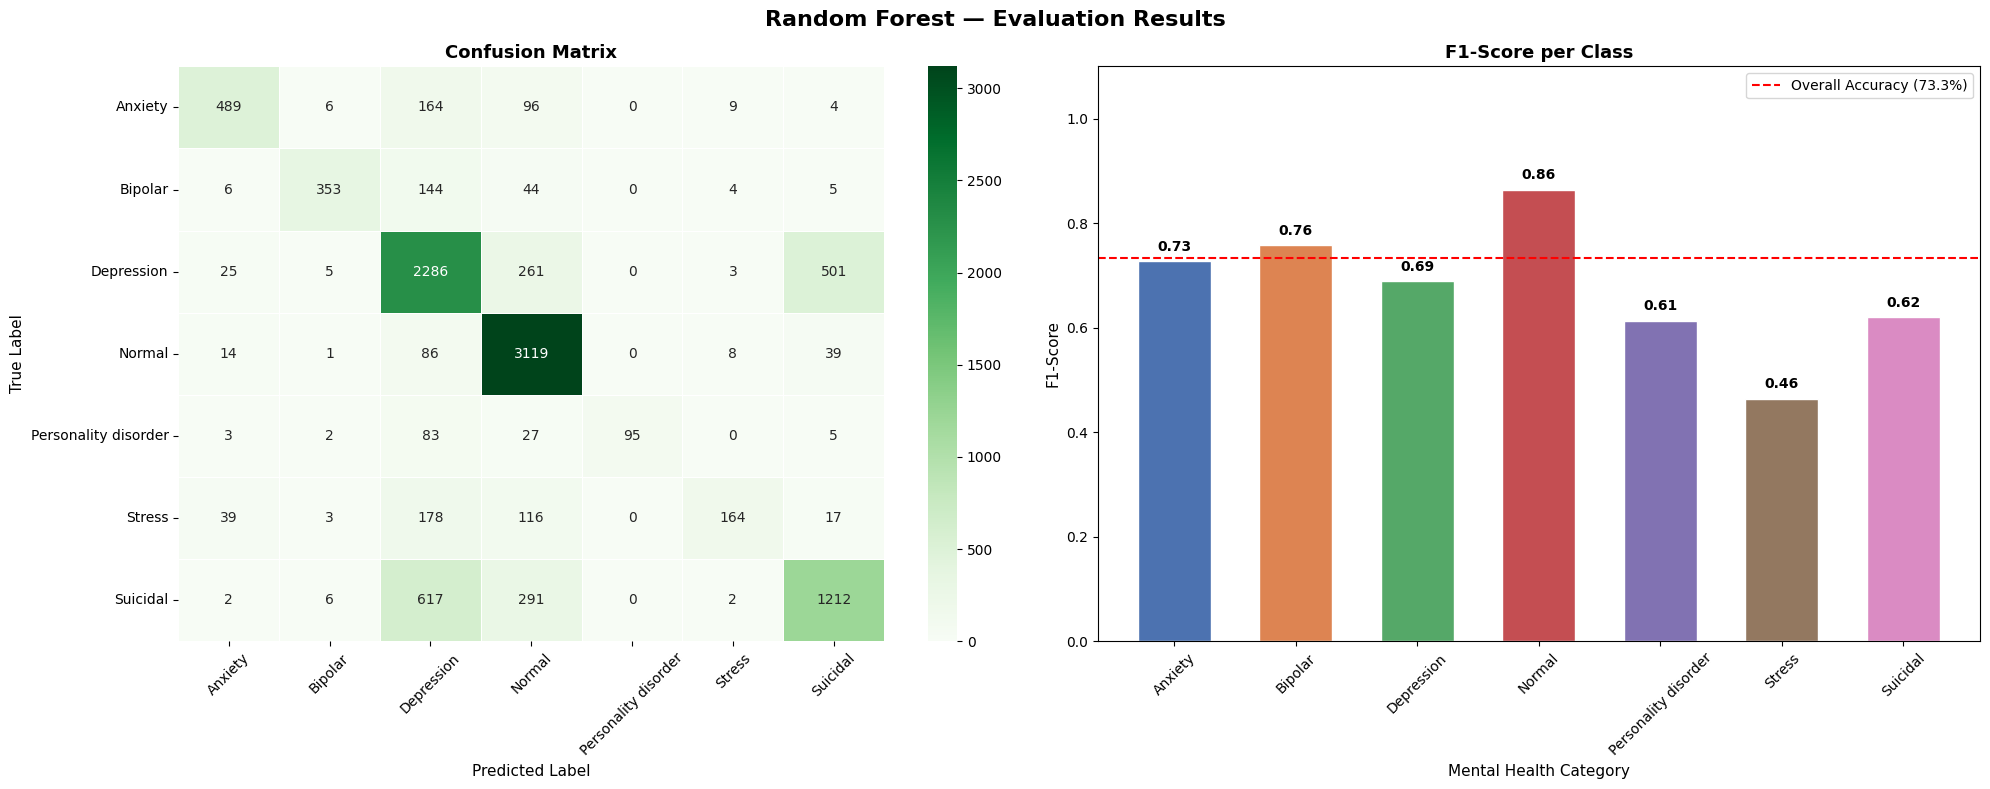


Chart saved as random_forest_results.png
Model saved as preprocessed/random_forest_model.pkl

  LIVE PREDICTION TEST WITH PRIORITY FLAG

  [1] Input    : I had a great day today, feeling really positive and happy!
      Predicted : Normal
      Confidence: 60.6%
      Priority  : ROUTINE

  [2] Input    : I feel so hopeless and empty, nothing makes me happy anymore
      Predicted : Depression
      Confidence: 41.7%
      Priority  : NEEDS HUMAN REVIEW

  [3] Input    : The constant anxiety is overwhelming, I am shaking and sweat
      Predicted : Anxiety
      Confidence: 48.7%
      Priority  : NEEDS HUMAN REVIEW

  [4] Input    : I hear voices and my thoughts are all over the place
      Predicted : Normal
      Confidence: 52.4%
      Priority  : ROUTINE

  [5] Input    : I just want to end it all, life has no meaning and I have a 
      Predicted : Suicidal
      Confidence: 65.4%
      Priority  : HIGH RISK

  PRIORITY FLAG LEGEND
  CRITICAL                    → Suicidal + conf

In [ ]:
# ============================================================
# CSC61304 - Assignment 3
# Mental Health Sentiment Analysis
# Step: Model Training - Random Forest (Comparison Model)
# ============================================================

import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_score,
                             recall_score, f1_score)

# ── 1. LOAD PREPROCESSED DATA ────────────────────────────────
try:
    X_train_tfidf, X_test_tfidf, y_train, y_test, le, tfidf = pickle.load(
        open('preprocessed/data.pkl', 'rb'))
    print("Data loaded successfully!")
    print(f"  Train : {X_train_tfidf.shape}")
    print(f"  Test  : {X_test_tfidf.shape}")
    print(f"  Classes: {list(le.classes_)}")
except FileNotFoundError:
    print("Error: preprocessed/data.pkl not found. Run preprocessing.py first.")
    exit()

# ── 2. TRAIN RANDOM FOREST ───────────────────────────────────
# Why Random Forest?
# - Handles non-linear relationships (e.g., "not happy" vs "happy")
# - class_weight=balanced handles the 7-class imbalance automatically
# - n_jobs=-1 uses all CPU cores for faster training
# - n_estimators=200 provides stable consensus among trees
# - max_depth=100 allows deep enough trees for text features

print("\nTraining Random Forest... (this may take a few minutes)")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train_tfidf, y_train)
print("Model trained successfully!")

# ── 3. PREDICT ───────────────────────────────────────────────
y_pred = rf.predict(X_test_tfidf)

# ── 4. METRICS ───────────────────────────────────────────────
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print(f"\n{'='*55}")
print(f"  RANDOM FOREST — RESULTS")
print(f"{'='*55}")
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"{'='*55}")

print(f"\nPer-Class Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── 5. VISUALIZATION 1 — CONFUSION MATRIX HEATMAP ───────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Random Forest — Evaluation Results',
             fontsize=16, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            ax=axes[0],
            linewidths=0.5)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# ── 6. VISUALIZATION 2 — PER CLASS F1 SCORE BAR CHART ───────
report = classification_report(y_test, y_pred,
                                target_names=le.classes_,
                                output_dict=True)
classes   = list(le.classes_)
f1_scores = [report[c]['f1-score'] for c in classes]
colors    = ['#4C72B0','#DD8452','#55A868','#C44E52',
             '#8172B2','#937860','#DA8BC3']

bars = axes[1].bar(classes, f1_scores, color=colors,
                   edgecolor='white', width=0.6)
axes[1].set_title('F1-Score per Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mental Health Category', fontsize=11)
axes[1].set_ylabel('F1-Score', fontsize=11)
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=acc, color='red', linestyle='--', linewidth=1.5,
                label=f'Overall Accuracy ({acc*100:.1f}%)')
axes[1].legend()
for bar, val in zip(bars, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('random_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as random_forest_results.png")

# ── 7. SAVE MODEL ────────────────────────────────────────────
pickle.dump(rf, open('preprocessed/random_forest_model.pkl', 'wb'))
print("Model saved as preprocessed/random_forest_model.pkl")

# ── 8. PRIORITY FLAG FUNCTION ────────────────────────────────
def get_priority(label, confidence):
    """
    Safety Threshold Logic:
    - Suicidal (any confidence) → always flagged, severity depends on confidence
    - Anxiety (high confidence) → High Risk
    - Any low confidence result → Human Review needed
    - Everything else          → Routine
    """
    if label == 'Suicidal':
        if confidence >= 70:
            priority = 'CRITICAL'
        else:
            priority = 'HIGH RISK'

    elif label == 'Anxiety' and confidence >= 70:
        priority = 'HIGH RISK'

    elif confidence < 50:
        priority = 'NEEDS HUMAN REVIEW'

    else:
        priority = 'ROUTINE'

    return priority

# ── 9. TEXT CLEANING FUNCTION ────────────────────────────────
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── 10. LIVE PREDICTION TEST ─────────────────────────────────
print(f"\n{'='*65}")
print("  LIVE PREDICTION TEST WITH PRIORITY FLAG")
print(f"{'='*65}")

test_sentences = [
    # ROUTINE — Normal
    "I had a great day today, feeling really positive and happy!",
    # ROUTINE — Depression
    "I feel so hopeless and empty, nothing makes me happy anymore",
    # HIGH RISK — Anxiety high confidence
    "The constant anxiety is overwhelming, I am shaking and sweating all the time and cannot calm down",
    # NEEDS HUMAN REVIEW — low confidence
    "I hear voices and my thoughts are all over the place",
    # CRITICAL — Suicidal high confidence
    "I just want to end it all, life has no meaning and I have a plan",
]

for i, sentence in enumerate(test_sentences, 1):
    cleaned    = clean_text(sentence)
    vectorized = tfidf.transform([cleaned])
    prediction = rf.predict(vectorized)[0]
    proba      = rf.predict_proba(vectorized)[0]
    confidence = proba.max() * 100
    label      = le.inverse_transform([prediction])[0]
    priority   = get_priority(label, confidence)  # ← fixed: now called correctly

    print(f"\n  [{i}] Input    : {sentence[:60]}")
    print(f"      Predicted : {label}")
    print(f"      Confidence: {confidence:.1f}%")
    print(f"      Priority  : {priority}")

print(f"\n{'='*65}")
print("  PRIORITY FLAG LEGEND")
print(f"{'='*65}")
print("  CRITICAL                    → Suicidal + confidence >= 70%")
print("  HIGH RISK                   → Suicidal + confidence < 70%")
print("  HIGH RISK                   → Anxiety  + confidence >= 70%")
print("  NEEDS HUMAN REVIEW          → Any label + confidence < 50%")
print("  ROUTINE                     → All other predictions")
print(f"{'='*65}")